# Reinforcement Learning for Blackjack: Initial Checkpoint

**Authors:** CSE 25 Project Team

## 1. Introduction

### Problem Statement

The goal of this project is to train an agent to play Blackjack by framing the game as a sequential decision-making problem under uncertainty. Unlike supervised learning, the agent must discover a policy that maximizes long-term returns through direct interaction with the environment — without labeled examples or prior knowledge of the game's transition dynamics.

Blackjack is a natural testbed for reinforcement learning: it has a small, fully enumerable state space, episodes are short and finite, and there exists a well-known optimal strategy (Basic Strategy) against which learned policies can be benchmarked.

### Relevance and Importance

Reinforcement learning is a foundational component of modern AI, underpinning breakthroughs from game-playing agents (AlphaGo, AlphaStar) to robotics and large language model alignment. The core challenge shared across all these domains — optimizing sequential decisions under uncertainty with delayed feedback — is precisely what Blackjack exercises in a tractable, well-understood setting. Mastering this environment builds crucial intuition for the explore/exploit tradeoff, value estimation, and policy improvement.

### Related Work

- **Basic Strategy:** Probability-based lookup tables define optimal moves based on the player's hand total and the dealer's upcard. This is the gold-standard human heuristic and serves as our rule-based baseline.
- **Monte Carlo Methods:** Sutton & Barto (*Reinforcement Learning: An Introduction*, 2nd ed.) use Blackjack as the canonical example for Monte Carlo policy evaluation and control, demonstrating how agents learn from complete episode trajectories without a model of the environment.
- **Temporal Difference Learning:** Q-learning (Watkins, 1989) is a TD method that updates value estimates after every step rather than waiting for episode completion. Its sample efficiency and convergence properties in tabular settings are well-characterized in the literature.

## 2. Data Sourcing and Processing

### The "Dataset"

Unlike supervised learning, RL does not rely on a static dataset. Data is generated dynamically through interaction with the environment. We use the `Gymnasium` library's `Blackjack-v1` environment (`sab=True` for Sutton & Barto rules), where the agent plays hands and receives reward signals based on outcomes.

### State Space (Features)

Each observation is a tuple of three components:

| Feature | Description | Range |
|---|---|---|
| `player_sum` | Total value of the player's current hand | 4 – 21 |
| `dealer_card` | Dealer's single face-up card (Ace = 1) | 1 – 10 |
| `usable_ace` | Whether the player holds an ace counting as 11 | 0 or 1 |

The total discrete state space has $32 \times 11 \times 2 = 704$ possible states, though in practice only a subset (roughly $200$) are reachable.

### Action Space

The standard `Blackjack-v1` environment offers exactly **two actions**:
- `0`: **Stand** — stop drawing cards.
- `1`: **Hit** — draw another card.

### Reward Structure

| Outcome | Reward |
|---|---|
| Player wins | +1.0 |
| Draw (push) | 0.0 |
| Player loses | -1.0 |

### Preprocessing

Because the state space is discrete and small, no preprocessing is required. The raw observation tuple is used directly as a dictionary key into each algorithm's Q-table. There are no missing values or outliers to handle.

## 3. Model Description

We implement and compare two tabular reinforcement learning algorithms, both evaluated against simple baselines. All models represent the policy implicitly through a **Q-table** — a lookup table mapping each (state, action) pair to an estimated value.

### Model Architecture (shared)

- **Q-Table shape:** `dict` over reachable states → `np.array([Q_stand, Q_hit])`. At most $704 \times 2 = 1{,}408$ learnable floats.
- **Exploration:** Epsilon-greedy — with probability $\varepsilon$ take a random action, otherwise $\arg\max_a Q(s,a)$.
- **Epsilon schedule:** $\varepsilon_0 = 1.0$, decaying by $\times 0.99995$ per episode, flooring at $0.05$.

---

### Algorithm 1: On-Policy First-Visit Monte Carlo Control

MC methods learn from **complete episode trajectories**. After each episode, the agent computes the discounted return $G$ from each visited (state, action) pair and updates Q-values using an incremental mean — no bootstrapping involved.

$$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$

Blackjack is a natural fit: episodes are short, finite, and rewards are observed at termination.

---

### Algorithm 2: Tabular Q-Learning (Off-Policy TD)

Q-learning updates after **every step** using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Off-policy means the update always targets the greedy value at $s'$, regardless of the actual exploratory action taken. Hyperparameters: $\alpha = 0.1$, $\gamma = 1.0$.

---

### Baseline Comparisons

| Baseline | Description |
|---|---|
| **Random Policy** | Selects Hit or Stand uniformly at random |
| **Stand-on-17+ Heuristic** | Hit if player sum < 17, else Stand |

---

### Evaluation Metrics

- **Primary:** Average episodic return over a 100k-episode evaluation run (greedy policy, no exploration).
- **Secondary:** Win rate, draw rate, loss rate.
- **Training diagnostic:** Smoothed learning curve (rolling average return vs. training episode).

---
## 4. Environment Setup

In [1]:
# !pip install gymnasium matplotlib numpy tqdm

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from tqdm import tqdm

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


In [2]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True uses Sutton & Barto rules

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Actions: 0=Stand, 1=Hit")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space:      Discrete(2)
Actions: 0=Stand, 1=Hit


In [3]:
# Sample episodes to understand the environment
print("=== Sample Episodes ===")
for episode in range(3):
    state, _ = env.reset()
    print(f"\nEpisode {episode + 1}: start state = {state}")
    done = False
    step = 0
    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        step += 1
        print(f"  Step {step}: {'Hit' if action else 'Stand':5s}  ->  state={next_state}  reward={reward}")
        state = next_state
    result = 'Win' if reward > 0 else ('Draw' if reward == 0 else 'Lose')
    print(f"  Result: {result}")

=== Sample Episodes ===

Episode 1: start state = (14, 10, 0)
  Step 1: Hit    ->  state=(24, 10, 0)  reward=-1.0
  Result: Lose

Episode 2: start state = (17, 8, 0)
  Step 1: Stand  ->  state=(17, 8, 0)  reward=-1.0
  Result: Lose

Episode 3: start state = (13, 6, 0)
  Step 1: Hit    ->  state=(16, 6, 0)  reward=0.0
  Step 2: Stand  ->  state=(16, 6, 0)  reward=-1.0
  Result: Lose


---
## 5. Baseline Policies

We establish two baselines before training any RL agent. These give reference points for assessing whether learning is actually working.

`evaluate_policy` reports the **average episodic return** (primary metric) and win/draw/loss rates.

In [4]:
def evaluate_policy(env, policy_fn, n_episodes=100_000):
    """
    Evaluate a greedy policy over many episodes (no exploration).
    Returns a dict: avg_return, win_rate, draw_rate, lose_rate.
    """
    wins, draws, losses = 0, 0, 0
    total_return = 0.0
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        ep_return = 0.0
        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        total_return += ep_return
        if reward > 0:   wins += 1
        elif reward == 0: draws += 1
        else:            losses += 1
    return dict(
        avg_return = total_return / n_episodes,
        win_rate   = wins   / n_episodes,
        draw_rate  = draws  / n_episodes,
        lose_rate  = losses / n_episodes,
    )


def print_results(label, results):
    print(f"{label:<30}  avg_return={results['avg_return']:+.4f}  "
          f"win={results['win_rate']:.2%}  draw={results['draw_rate']:.2%}  lose={results['lose_rate']:.2%}")

In [5]:
random_policy    = lambda state: env.action_space.sample()
threshold_policy = lambda state: 1 if state[0] < 17 else 0

baseline_random    = evaluate_policy(env, random_policy)
baseline_threshold = evaluate_policy(env, threshold_policy)

print_results("Random Policy",          baseline_random)
print_results("Stand-on-17+ Heuristic", baseline_threshold)

Random Policy                   avg_return=-0.3919  win=28.38%  draw=4.05%  lose=67.57%
Stand-on-17+ Heuristic          avg_return=-0.0741  win=41.21%  draw=10.17%  lose=48.62%


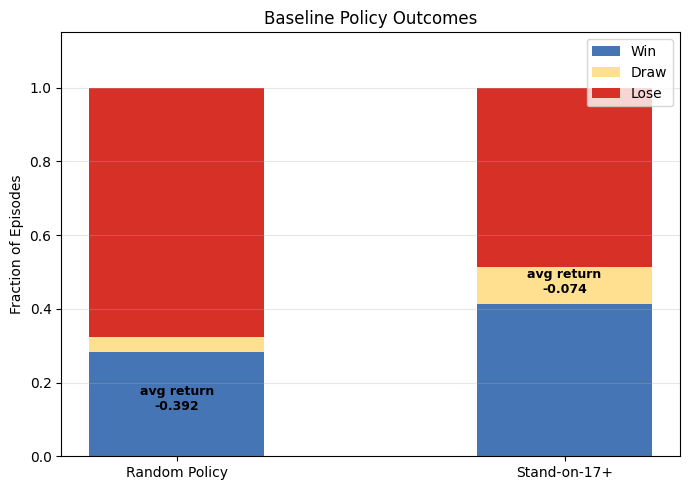

In [6]:
# Stacked bar chart: Win / Draw / Lose breakdown for baselines
labels  = ["Random Policy", "Stand-on-17+"]
results = [baseline_random, baseline_threshold]

wins   = [r['win_rate']  for r in results]
draws  = [r['draw_rate'] for r in results]
loses  = [r['lose_rate'] for r in results]

x = np.arange(len(labels))
bar_w = 0.45

fig, ax = plt.subplots(figsize=(7, 5))
bars_w = ax.bar(x, wins,  bar_w, label='Win',  color='#4575b4')
bars_d = ax.bar(x, draws, bar_w, label='Draw', color='#fee090', bottom=wins)
bars_l = ax.bar(x, loses, bar_w, label='Lose', color='#d73027',
                bottom=[w + d for w, d in zip(wins, draws)])

for bar, r in zip(bars_w, results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            r['avg_return'] + 0.51, f"avg return\n{r['avg_return']:+.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Fraction of Episodes')
ax.set_title('Baseline Policy Outcomes')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Monte Carlo Control

### What is Monte Carlo RL?

Monte Carlo methods estimate value functions by averaging returns from **complete episode trajectories**. The agent plays a full hand, observes the final reward, then looks back at every (state, action) pair it visited and updates Q-values based on the actual total return received.

### Algorithm: First-Visit MC Control

1. **Generate episode** using epsilon-greedy policy.
2. **Compute returns** backward: $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
3. **Update Q-values** for each *(state, action)* visited for the first time in the episode:
   $$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$
4. **Decay epsilon** to shift from exploration toward exploitation.

In [7]:
def train_monte_carlo(
    env,
    n_episodes=500_000,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="MC Training", leave=False):
        state, _ = env.reset()
        episode = []
        done = False

        # Generate episode
        while not done:
            action = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state

        ep_returns.append(sum(r for _, _, r in episode))

        # First-visit MC update (backward)
        G = 0.0
        visited = set()
        for s, a, r in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_count[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / returns_count[s][a]

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [8]:
mc_Q, mc_returns = train_monte_carlo(env, n_episodes=500_000)
mc_policy = lambda state: int(np.argmax(mc_Q[state]))

mc_results = evaluate_policy(env, mc_policy)
print_results("Monte Carlo Control", mc_results)

MC Training:   0%|          | 0/500000 [00:00<?, ?it/s]

MC Training:   0%|          | 1742/500000 [00:00<00:28, 17414.12it/s]

MC Training:   1%|          | 3640/500000 [00:00<00:27, 18329.27it/s]

MC Training:   1%|          | 5473/500000 [00:00<00:27, 17671.33it/s]

MC Training:   1%|▏         | 7243/500000 [00:00<00:28, 17422.79it/s]

...

MC Training:  99%|█████████▊| 493583/500000 [00:26<00:00, 18449.50it/s]

MC Training:  99%|█████████▉| 495447/500000 [00:26<00:00, 18502.49it/s]

MC Training:  99%|█████████▉| 497306/500000 [00:26<00:00, 18528.02it/s]

MC Training: 100%|█████████▉| 499160/500000 [00:26<00:00, 18370.86it/s]

Monte Carlo Control             avg_return=-0.0438  win=43.65%  draw=8.32%  lose=48.03%


---
## 7. Tabular Q-Learning (Off-Policy TD)

Q-learning updates the Q-table after **every step** using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

The $\max_{a'}$ makes it **off-policy** — updates always target the greedy value at $s'$, regardless of the agent's exploratory behavior. This can lead to faster convergence than MC since the agent learns from every transition rather than only at episode end.

In [9]:
def train_q_learning(
    env,
    n_episodes=500_000,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="Q-Learning Training", leave=False):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # Epsilon-greedy action selection
            a = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[s]))

            s2, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            ep_return += r

            # Q-learning update
            best_next = 0.0 if done else float(np.max(Q[s2]))
            Q[s][a] += alpha * (r + gamma * best_next - float(Q[s][a]))
            s = s2

        ep_returns.append(ep_return)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [10]:
ql_Q, ql_returns = train_q_learning(env, n_episodes=500_000)
ql_policy = lambda state: int(np.argmax(ql_Q[state]))

ql_results = evaluate_policy(env, ql_policy)
print_results("Q-Learning", ql_results)

Q-Learning Training:   0%|          | 0/500000 [00:00<?, ?it/s]

Q-Learning Training:   0%|          | 1895/500000 [00:00<00:26, 18948.26it/s]

Q-Learning Training:   1%|          | 3851/500000 [00:00<00:25, 19307.40it/s]

Q-Learning Training:   1%|          | 5840/500000 [00:00<00:25, 19571.10it/s]

Q-Learning Training:   2%|▏         | 7801/500000 [00:00<00:25, 19583.83it/s]

...

Q-Learning Training:  99%|█████████▊| 492927/500000 [00:26<00:00, 18424.64it/s]

Q-Learning Training:  99%|█████████▉| 494798/500000 [00:26<00:00, 18505.50it/s]

Q-Learning Training:  99%|█████████▉| 496683/500000 [00:26<00:00, 18606.40it/s]

Q-Learning Training: 100%|█████████▉| 498600/500000 [00:26<00:00, 18774.22it/s]

Q-Learning                      avg_return=-0.0619  win=42.61%  draw=8.60%  lose=48.80%


---
## 8. Results and Comparison

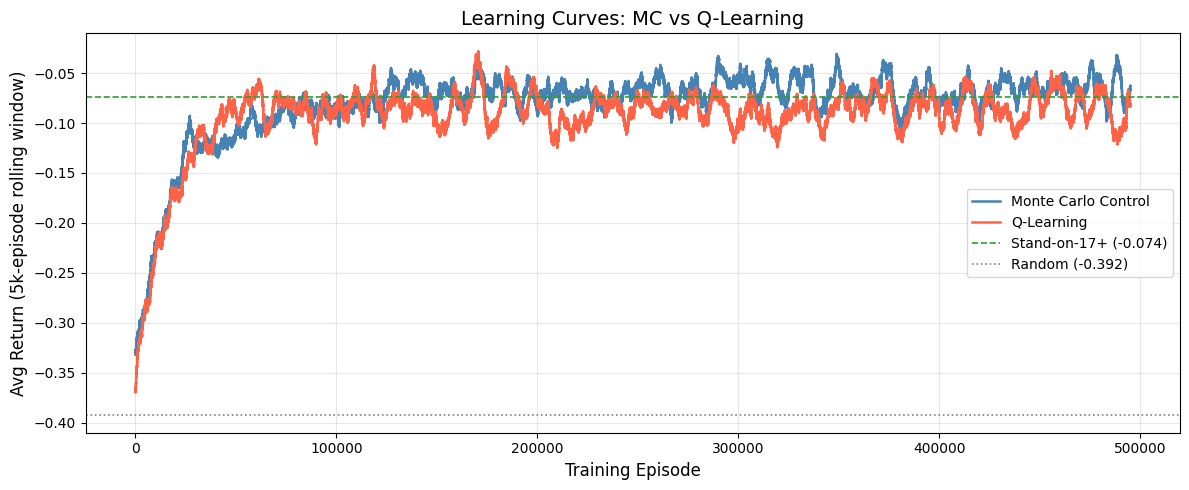

In [11]:
# --- Learning Curves ---
def smooth(data, window=5_000):
    return np.convolve(data, np.ones(window) / window, mode='valid')


fig, ax = plt.subplots(figsize=(12, 5))

for returns, label, color in [
    (mc_returns, 'Monte Carlo Control', 'steelblue'),
    (ql_returns, 'Q-Learning',          'tomato'),
]:
    s = smooth(returns, window=5_000)
    ax.plot(np.arange(len(s)), s, label=label, color=color, linewidth=1.8)

# Baseline reference lines
ax.axhline(y=baseline_threshold['avg_return'], color='#2ca02c', linestyle='--',
           linewidth=1.2, label=f"Stand-on-17+ ({baseline_threshold['avg_return']:+.3f})")
ax.axhline(y=baseline_random['avg_return'], color='gray', linestyle=':',
           linewidth=1.2, label=f"Random ({baseline_random['avg_return']:+.3f})")

ax.set_xlabel('Training Episode', fontsize=12)
ax.set_ylabel('Avg Return (5k-episode rolling window)', fontsize=12)
ax.set_title('Learning Curves: MC vs Q-Learning', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

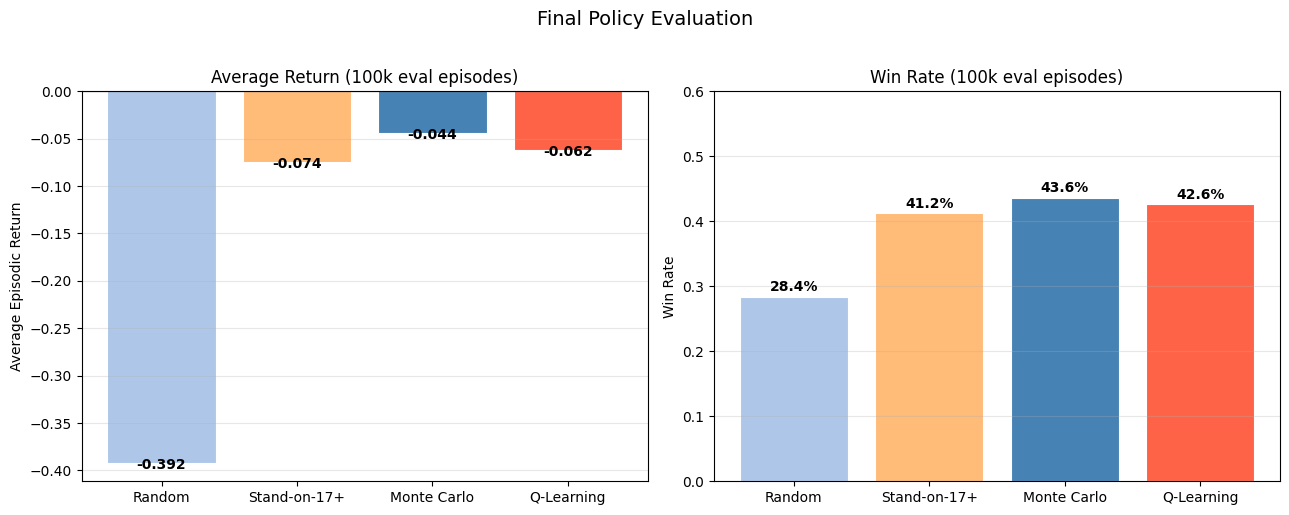

In [12]:
# --- Final Evaluation Bar Chart ---
all_labels  = ["Random", "Stand-on-17+", "Monte Carlo", "Q-Learning"]
all_results = [baseline_random, baseline_threshold, mc_results, ql_results]
colors      = ['#aec7e8', '#ffbb78', 'steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg Return
returns = [r['avg_return'] for r in all_results]
axes[0].bar(all_labels, returns, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(returns):
    axes[0].text(i, v + (0.004 if v >= 0 else -0.010), f"{v:+.3f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Average Episodic Return')
axes[0].set_title('Average Return (100k eval episodes)')
axes[0].grid(axis='y', alpha=0.3)

# Win Rate
win_rates = [r['win_rate'] for r in all_results]
axes[1].bar(all_labels, win_rates, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(win_rates):
    axes[1].text(i, v + 0.004, f"{v:.1%}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate (100k eval episodes)')
axes[1].set_ylim(0, 0.60)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Final Policy Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

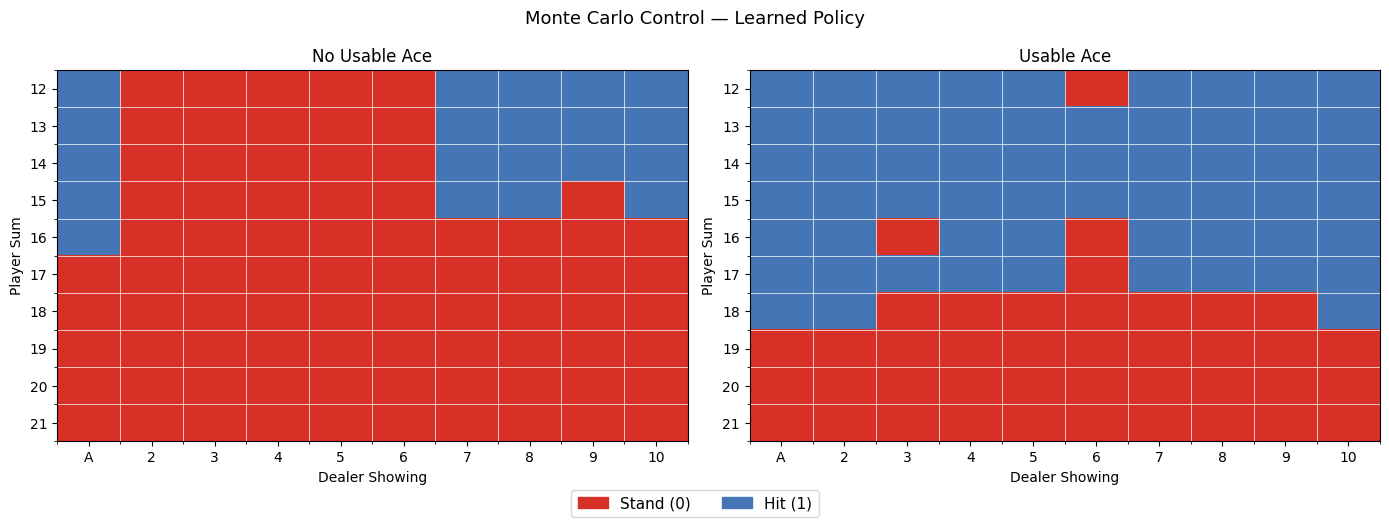

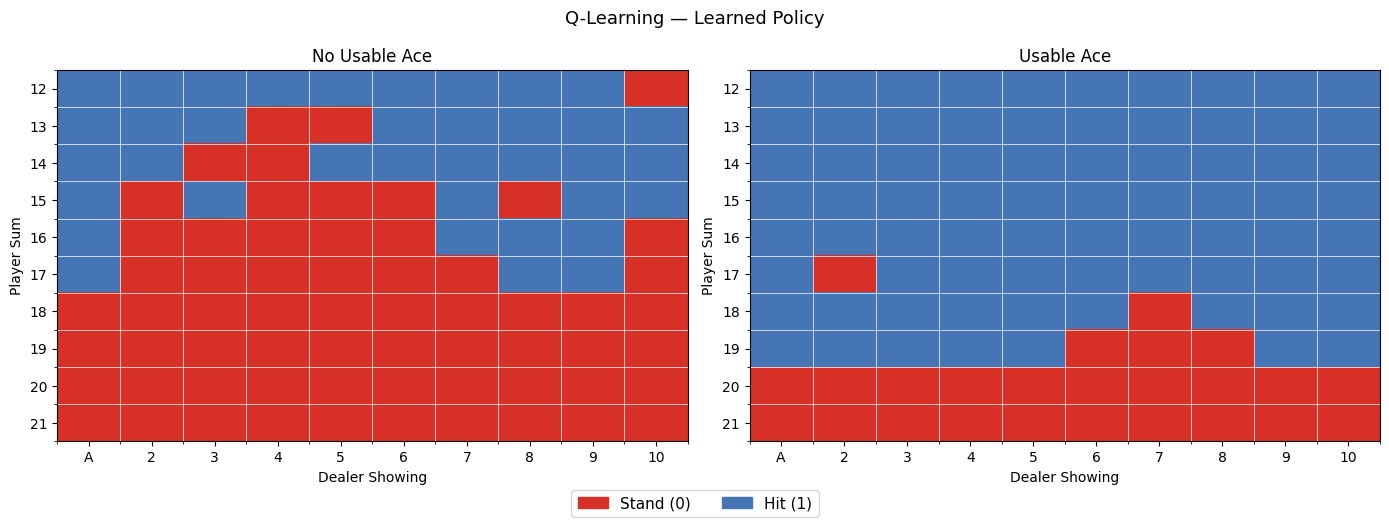

In [13]:
# --- Policy Heatmaps ---
def plot_policy_heatmap(Q, title):
    """
    Visualize the greedy policy learned by a Q-table.
    Rows = player sum (12-21), Cols = dealer showing (1-10).
    Blue = Hit, Red = Stand. Left panel: no usable ace. Right: usable ace.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    for ax, usable_ace in zip(axes, [False, True]):
        player_sums  = range(12, 22)
        dealer_cards = range(1, 11)
        policy_grid  = np.zeros((len(player_sums), len(dealer_cards)))

        for i, ps in enumerate(player_sums):
            for j, dc in enumerate(dealer_cards):
                state = (ps, dc, int(usable_ace))
                policy_grid[i, j] = int(np.argmax(Q[state]))

        # Custom colormap: 0=Stand (red), 1=Hit (blue)
        cmap = plt.cm.colors.ListedColormap(['#d73027', '#4575b4'])
        ax.imshow(policy_grid, cmap=cmap, vmin=0, vmax=1,
                  aspect='auto', origin='upper')

        # Grid lines and labels
        ax.set_xticks(np.arange(10))
        ax.set_xticklabels(['A' if c == 1 else str(c) for c in dealer_cards])
        ax.set_yticks(np.arange(len(player_sums)))
        ax.set_yticklabels(list(player_sums))
        ax.set_xlabel('Dealer Showing')
        ax.set_ylabel('Player Sum')
        ace_label = 'Usable Ace' if usable_ace else 'No Usable Ace'
        ax.set_title(ace_label)

        # Draw grid
        ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.5)

    stand_patch = mpatches.Patch(color='#d73027', label='Stand (0)')
    hit_patch   = mpatches.Patch(color='#4575b4', label='Hit (1)')
    fig.legend(handles=[stand_patch, hit_patch], loc='lower center',
               ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)
    plt.tight_layout()
    plt.show()


plot_policy_heatmap(mc_Q, 'Monte Carlo Control — Learned Policy')
plot_policy_heatmap(ql_Q, 'Q-Learning — Learned Policy')

In [14]:
# --- Summary Table ---
print(f"{'Algorithm':<28} {'Avg Return':>12} {'Win Rate':>10} {'Draw Rate':>11} {'Lose Rate':>11}")
print("-" * 76)
for label, r in zip(all_labels, all_results):
    print(f"{label:<28} {r['avg_return']:>+12.4f} {r['win_rate']:>10.2%} {r['draw_rate']:>11.2%} {r['lose_rate']:>11.2%}")

Algorithm                      Avg Return   Win Rate   Draw Rate   Lose Rate
----------------------------------------------------------------------------
Random                            -0.3919     28.38%       4.05%      67.57%
Stand-on-17+                      -0.0741     41.21%      10.17%      48.62%
Monte Carlo                       -0.0438     43.65%       8.32%      48.03%
Q-Learning                        -0.0619     42.61%       8.60%      48.80%
